In [2]:
library(glmnet) 
library(survival)
library(dplyr)
library("DESeq2")
library("tidyverse")

In [3]:
exp_data <- read.csv("./../data/TCGA_data/OV_exp.tsv", sep = "\t")
row.names(exp_data) <- exp_data$X
exp_data$X <- NULL
exp_data <- as.data.frame(t(exp_data))
print(dim(exp_data))

keep = rowSums(exp_data >= 10) >= 5
exp_data <- exp_data[keep,]
print(nrow(exp_data))

[1] 19962   421
[1] 18245


In [4]:
clinical_data <- read.csv("./../data/TCGA_data/OV_clinical.tsv", sep = "\t")
rownames(clinical_data) <- clinical_data$barcode
print(dim(clinical_data))

clinical_data <- filter(clinical_data, OS_time != 0)
print(dim(clinical_data))

exp_data <- exp_data[ , rownames(clinical_data) ]
print(dim(exp_data))

[1] 421  64
[1] 420  64
[1] 18245   420


In [5]:
## Variance stabilizing transformation [Sample- level Quality Control]
vst_exp <- vst(as.matrix(exp_data), blind = FALSE)
vst_exp <- as.data.frame(t(vst_exp))
print(dim(vst_exp))

[1]   420 18245


In [6]:
table(rownames(vst_exp) == rownames(clinical_data))


TRUE 
 420 

## Intersection with marker genes

In [7]:
scRNA_seq_DEGs <- read.csv("./results/PRJCA005422_pseudobulk_edgeR_DEGs_PValue05.csv")
print(dim(scRNA_seq_DEGs))
head(scRNA_seq_DEGs, 5)

[1] 809   6


,gene,logFC,logCPM,F,PValue,FDR
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,REG1A,7.660154,4.37529986,46.38830,1.137924e-05,0.1947429
2,CRYM,3.873289,-1.40909210,29.38830,2.238039e-05,0.1947429
3,BTBD11,3.340843,-1.66548112,25.76897,5.139688e-05,0.2595664
4,SCGB1C2,4.418915,-0.03722045,27.47811,5.966015e-05,0.2595664
5,RP11-400N13.2,5.035422,1.37844721,28.41467,9.153188e-05,0.3185859


In [8]:
common_genes <- intersect(colnames(vst_exp), scRNA_seq_DEGs$gene)
print(length(common_genes))

[1] 645


## Univariate Cox regression

In [9]:
univariate_cox <- function(vst_data,
                           time_col = "OS_time",
                           event_col = "vital_status") {
  
  # Identify gene columns
  gene_cols <- setdiff(
    colnames(vst_data),
    c(time_col, event_col)
  )
  
  # Check survival variables
  if (!all(c(time_col, event_col) %in% colnames(vst_data))) {
    stop("OS_time and/or vital_status not found in vst_data.")
  }
  
  # Run Cox regression for each gene
  results <- lapply(gene_cols, function(gene) {
    
    # Keep complete observations for this gene
    dat <- data.frame(
      time = vst_data[[time_col]],
      event = vst_data[[event_col]],
      expression = vst_data[[gene]]
    )
    
    dat <- dat[complete.cases(dat), ]
    
    # Cox model
    fit <- tryCatch(
      coxph(
        Surv(time, event) ~ expression,
        data = dat
      ),
      error = function(e) NULL
    )
    
    # Return NA if model failed
    if (is.null(fit)) {
      return(data.frame(
        Gene = gene,
        coefficient_beta = NA_real_,
        Hazard_Ratio = NA_real_,
        wald_test = NA_real_,
        p.value = NA_real_
      ))
    }
    
    # Extract results
    s <- summary(fit)
    
    data.frame(
      Gene = gene,
      coefficient_beta = unname(s$coef[1, "coef"]),
      Hazard_Ratio = unname(s$coef[1, "exp(coef)"]),
      wald_test = unname(s$wald["test"]),
      p.value = unname(s$wald["pvalue"])
    )
  })
  
  # Combine results
  results <- do.call(rbind, results)
  
  # Sort by pvalue
  results <- results[order(results$p.value), ]
  
  # Reset row names
  rownames(results) <- NULL
  
  return(results)
}

In [10]:
vst_clin_univariate_df <- merge(
    vst_exp[, common_genes, drop = FALSE],
    clinical_data[, c("OS_time", "vital_status")],
    by = "row.names"
)

rownames(vst_clin_univariate_df) <- vst_clin_univariate_df$Row.names
vst_clin_univariate_df$Row.names <- NULL
print(dim(vst_clin_univariate_df))

univariate_res <- univariate_cox(vst_clin_univariate_df)

[1] 420 647


In [11]:
print(dim(univariate_res))
# Filter significant genes
sig_univariate_res <- subset(univariate_res, p.value < 0.05)
print(dim(sig_univariate_res))
head(sig_univariate_res, 10)

[1] 645   5
[1] 50  5


,Gene,coefficient_beta,Hazard_Ratio,wald_test,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,FCGBP,0.1558067,1.1686003,17.52,2.841155e-05
2,CXCL13,-0.1508576,0.8599702,11.37,7.476048e-04
3,ANGPTL4,0.1594027,1.1728102,9.67,1.868870e-03
4,CD3G,-0.2213019,0.8014747,8.21,4.170878e-03
5,RXFP1,-0.3266799,0.7213146,8.16,4.278735e-03
6,DKK1,0.2265267,1.2542361,7.42,6.455949e-03
7,PRKAR1B,0.2132163,1.2376523,7.26,7.066466e-03
8,RALGAPB,0.3085299,1.3614223,6.98,8.258789e-03
9,CCDC28A,0.2320386,1.2611684,6.81,9.075191e-03


In [12]:
for ( i in sig_univariate_res$Gene){
    cat(i)
    cat("\n")
}

FCGBP
CXCL13
ANGPTL4
CD3G
RXFP1
DKK1
PRKAR1B
RALGAPB
CCDC28A
ICOS
SDCBP2
JCHAIN
CYP24A1
PRRG1
VTA1
TMCO3
MZB1
TGFBI
FZD5
CCR7
TLE2
CHN1
ANXA8
GBP5
CD3D
TBC1D7
FKBP3
TRIM4
CALB1
SRMS
AHNAK2
KLRB1
PTK6
EMC9
RPRD1B
RASSF2
TGM7
HOXC8
ADCY9
TOX
RAB20
SLFN5
CCDC71L
DGKZ
CD27
TNFRSF10C
RP1
CAPN9
ATP6V1G2
TGM1


In [13]:
## write.csv(sig_univariate_res, "./results/TCGA_univariate_cox_results.csv", row.names = FALSE)

## Multivariate Cox Regression Analysis

In [15]:
library(survminer)

In [16]:
candidate_genes <- sig_univariate_res$Gene
lasso_data <- vst_clin_univariate_df[
    ,
    c(candidate_genes, "OS_time", "vital_status")
]
print(dim(lasso_data))

[1] 420  52


In [17]:
x_all <- as.matrix(
    lasso_data[, candidate_genes, drop = FALSE]
)

y <- Surv(
    lasso_data$OS_time,
    lasso_data$vital_status
)

print(dim(x_all))
print(dim(y))

[1] 420  50
[1] 420   2


In [18]:
set.seed(123)

# hyperparameters
alpha_val        <- 1           # 1 = LASSO, 0<alpha<1 = elastic-net
nfolds_cv        <- 10
subsample_prop   <- 0.8
use_lambda       <- "lambda.min" # or "lambda.1se"

cv_lasso <- cv.glmnet(
    x = x_all,
    y = y,
    family = "cox",
    alpha = alpha_val,
    nfolds = nfolds_cv,
    type.measure = "deviance",
    standardize = TRUE
)

coef_min <- coef(
    cv_lasso,
    s = use_lambda
)

selected_genes_min <- rownames(coef_min)[
    coef_min[, 1] != 0
]

print(length(selected_genes_min))
selected_genes_min

[1] 34


[1] "FCGBP"   "CXCL13"  "ANGPTL4" "CD3G"    "RXFP1"   "DKK1"    "PRKAR1B"
 [8] "RALGAPB" "CCDC28A" "ICOS"    "JCHAIN"  "CYP24A1" "PRRG1"   "VTA1"   
[15] "TMCO3"   "TGFBI"   "CCR7"    "CHN1"    "ANXA8"   "GBP5"    "FKBP3"  
[22] "TRIM4"   "CALB1"   "AHNAK2"  "RPRD1B"  "RASSF2"  "TGM7"    "HOXC8"  
[29] "RAB20"   "SLFN5"   "CCDC71L" "DGKZ"    "RP1"     "CAPN9"

In [19]:
# --------------------------------
# Stability selection
# --------------------------------

freq_threshold <- 0.6
n_repeats <- 500
subsample_prop <- 0.70
use_lambda   <- "lambda.min" # or "lambda.1se"

set.seed(124)

# Make sure x_all and clinical data are aligned
stopifnot(
        nrow(x_all) == length(y)
    )


n <- nrow(x_all)

# Initialize with NA so failed repetitions
# are not counted as non-selection

sel_mat <- matrix(
    NA_real_,
    nrow = n_repeats,
    ncol = ncol(x_all)
)

colnames(sel_mat) <- colnames(x_all)

message(
    "Starting stability selection (",
    n_repeats,
    " repeats)..."
)

for (i in seq_len(n_repeats)) {

    # Random subsampling without replacement
    idx <- sample(
        seq_len(n),
        size = floor(subsample_prop * n),
        replace = FALSE
    )

    x_sub <- x_all[idx, , drop = FALSE]
    y_sub <- y[idx]

    # Fit cross-validated penalized Cox model
    cvsub <- tryCatch(

        cv.glmnet(
            x = x_sub,
            y = y_sub,
            family = "cox",
            alpha = alpha_val,
            nfolds = nfolds_cv,
            standardize = TRUE
        ),

        error = function(e) {
            message(
                "Repeat ", i,
                " failed: ",
                e$message
            )
            return(NULL)
        }
    )

    # Skip failed repetitions
    if (is.null(cvsub)) {
        next
    }

    # Select lambda
    lambda_val <- if (
        use_lambda == "lambda.1se"
    ) {
        cvsub$lambda.1se
    } else {
        cvsub$lambda.min
    }

    # Extract coefficients
    cfs <- coef(
        cvsub,
        s = lambda_val
    )

    # Convert to numeric vector
    cfs <- as.numeric(cfs)

    # Successful repeat:
    # initially no genes selected
    sel_mat[i, ] <- 0

    # Mark selected genes
    sel_mat[i, cfs != 0] <- 1

    if (i %% 10 == 0) {
        message("Completed repeat: ", i)
    }
}

# --------------------------------
# Selection frequency
# --------------------------------

sel_freq <- colMeans(
    sel_mat,
    na.rm = TRUE
)

# Sort genes by selection frequency
gene_freq_sorted <- sort(
    sel_freq,
    decreasing = TRUE
)

# --------------------------------
# Stable genes
# --------------------------------

stable_genes <- names(
    gene_freq_sorted[
        gene_freq_sorted >= freq_threshold
    ]
)

message(
    "Number of stable genes: ",
    length(stable_genes)
)

stable_genes

Starting stability selection (500 repeats)...

Completed repeat: 10

Completed repeat: 20

Completed repeat: 30

Completed repeat: 40

Completed repeat: 50

Completed repeat: 60

Completed repeat: 70

Completed repeat: 80

Completed repeat: 90

Completed repeat: 100

Completed repeat: 110

Completed repeat: 120

Completed repeat: 130

Completed repeat: 140

Completed repeat: 150

Completed repeat: 160

Completed repeat: 170

Completed repeat: 180

Completed repeat: 190

Completed repeat: 200

Completed repeat: 210

Completed repeat: 220

Completed repeat: 230

Completed repeat: 240

Completed repeat: 250

Completed repeat: 260

Completed repeat: 270

Completed repeat: 280

Completed repeat: 290

Completed repeat: 300

Completed repeat: 310

Completed repeat: 320

Completed repeat: 330

Completed repeat: 340

Completed repeat: 350

Completed repeat: 360

Completed repeat: 370

Completed repeat: 380

Completed repeat: 390

Completed repeat: 400

Completed repeat: 410

Completed repeat: 4

[1] "FCGBP"   "ANGPTL4" "CCDC28A" "RXFP1"   "PRKAR1B" "VTA1"    "PRRG1"  
 [8] "CALB1"   "DKK1"    "CXCL13"  "RALGAPB"

In [20]:
gene_freq_sorted

FCGBP   ANGPTL4   CCDC28A     RXFP1   PRKAR1B      VTA1     PRRG1     CALB1 
    0.888     0.828     0.814     0.792     0.768     0.752     0.738     0.690 
     DKK1    CXCL13   RALGAPB     HOXC8      CHN1      CD3G      DGKZ     CAPN9 
    0.656     0.644     0.632     0.582     0.526     0.512     0.498     0.498 
  CCDC71L    RPRD1B      CCR7     TMCO3   CYP24A1       RP1    JCHAIN    AHNAK2 
    0.494     0.490     0.480     0.478     0.458     0.376     0.358     0.352 
    SLFN5      GBP5     TRIM4     TGFBI    RASSF2      TGM7    SDCBP2     RAB20 
    0.336     0.332     0.330     0.322     0.320     0.296     0.272     0.270 
     ICOS     ANXA8     FKBP3      FZD5      EMC9     KLRB1      SRMS      TLE2 
    0.264     0.258     0.242     0.232     0.222     0.220     0.214     0.202 
 ATP6V1G2    TBC1D7      PTK6      MZB1       TOX      TGM1 TNFRSF10C     ADCY9 
    0.200     0.152     0.142     0.118     0.114     0.112     0.078     0.074 
     CD27      CD3D 
    0.022     0.002

In [21]:
selected_genes <- c('FCGBP','ANGPTL4','CCDC28A','RXFP1','PRKAR1B','VTA1','PRRG1','CALB1','DKK1','CXCL13','RALGAPB')
df_scaled <- lasso_data[ ,  c(selected_genes, "OS_time", "vital_status")]
df_scaled[, selected_genes] <- scale(df_scaled[, selected_genes])
print(dim(df_scaled))


# Model fitting
formula_genes <- as.formula(paste0("Surv(", 'OS_time', ", ", 'vital_status', ") ~ ", paste(selected_genes, collapse = " + ")))
cox_final_model <- coxph(formula_genes, data = df_scaled)
summary(cox_final_model)
# coef(cox_final_model)
risk_score <- predict(cox_final_model, type = "lp")  # linear predictor
df_scaled$risk_score <- risk_score

# Median Risk score Cutoff
cut_opt <- median(
    df_scaled$risk_score,
    na.rm = TRUE
)
print(cut_opt)
df_scaled$risk_group <- ifelse(df_scaled$risk_score > cut_opt, "High", "Low")
df_scaled$risk_group <- factor(
  df_scaled$risk_group,
  levels = c("Low", "High")
)

[1] 420  13


Call:
coxph(formula = formula_genes, data = df_scaled)

  n= 420, number of events= 262 

            coef exp(coef) se(coef)      z Pr(>|z|)    
FCGBP    0.14923   1.16094  0.06511  2.292 0.021907 *  
ANGPTL4  0.13367   1.14302  0.06605  2.024 0.043000 *  
CCDC28A  0.12585   1.13412  0.06084  2.068 0.038600 *  
RXFP1   -0.20885   0.81152  0.07566 -2.760 0.005777 ** 
PRKAR1B  0.21610   1.24123  0.06786  3.185 0.001449 ** 
VTA1     0.17681   1.19340  0.07465  2.369 0.017854 *  
PRRG1    0.14334   1.15412  0.06435  2.228 0.025914 *  
CALB1    0.20909   1.23256  0.06125  3.414 0.000641 ***
DKK1     0.18001   1.19722  0.06560  2.744 0.006070 ** 
CXCL13  -0.24270   0.78451  0.06982 -3.476 0.000509 ***
RALGAPB  0.19306   1.21296  0.06865  2.812 0.004920 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

        exp(coef) exp(-coef) lower .95 upper .95
FCGBP      1.1609     0.8614    1.0219    1.3190
ANGPTL4    1.1430     0.8749    1.0042    1.3010
CCDC28A    1.1341     0

[1] -0.01261388


In [22]:
coef(cox_final_model)

FCGBP    ANGPTL4    CCDC28A      RXFP1    PRKAR1B       VTA1      PRRG1 
 0.1492293  0.1336698  0.1258527 -0.2088452  0.2161026  0.1768102  0.1433423 
     CALB1       DKK1     CXCL13    RALGAPB 
 0.2090943  0.1800061 -0.2426962  0.1930621

In [23]:
as.data.frame(coef(cox_final_model))

,coef(cox_final_model)
,<dbl>
FCGBP,0.1492293
ANGPTL4,0.1336698
CCDC28A,0.1258527
RXFP1,-0.2088452
PRKAR1B,0.2161026
VTA1,0.1768102
PRRG1,0.1433423
CALB1,0.2090943
DKK1,0.1800061


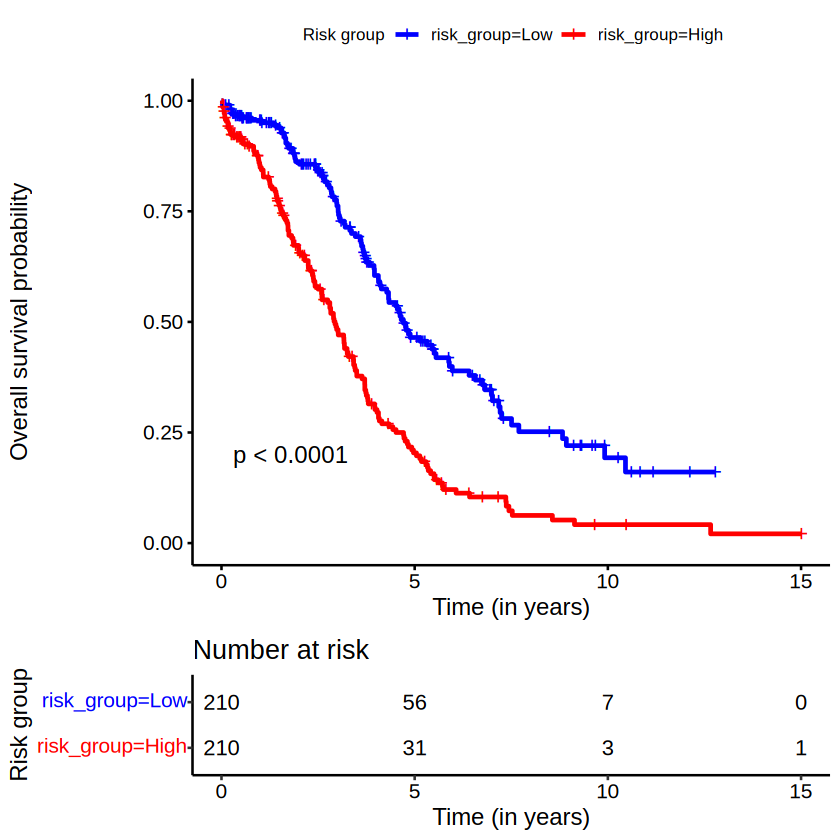

In [24]:
# KM
fit_km <- survfit(Surv(df_scaled[["OS_time"]]/365.25, df_scaled[["vital_status"]]) ~ risk_group, data = df_scaled)
ggsurvplot(fit_km, data = df_scaled, pval = TRUE, 
           risk.table = TRUE,  
            xlab = "Time (in years)",
            ylab = "Overall survival probability",
            legend.title = "Risk group",
            palette = c("blue", "red"))

In [25]:
# png(filename = "./results/TCGA_riskStratification_survival_plot.png", width = 1800, height = 1500, res = 300)
# ggsurvplot(fit_km, data = df_scaled, pval = TRUE, 
#            risk.table = TRUE,  
#             xlab = "Time (in years)",
#             ylab = "Overall survival probability",
#             legend.title = "Risk group",
#             palette = c("blue", "red"))
# dev.off()

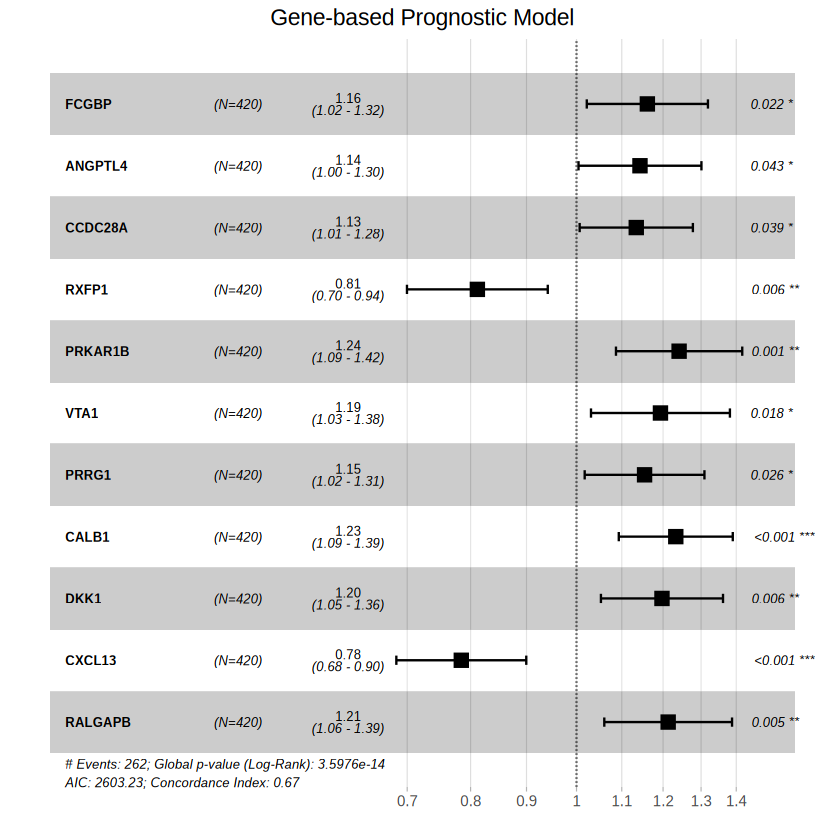

In [26]:
ggforest(
  cox_final_model,
  data = df_scaled,
  main = "Gene-based Prognostic Model",
  noDigits = 2
)

In [27]:
# png(filename = "./results/TCGA_gene_prognostic_model.png", width = 1800, height = 2100, res = 300)
# ggforest(
#   cox_final_model,
#   data = df_scaled,
#   main = "Gene-based Prognostic Model",
#   #cpositions = c(0.02, 0.22, 0.4),
#   #fontsize = 1.0,
#   #refLabel = "Reference",
#   noDigits = 2
# )
# dev.off()

## Clinical Model

In [28]:
## Data Filtering
filtered_clinical_data <- filter(clinical_data, figo_stage != "" & !is.na(age_at_diagnosis))
print(dim(filtered_clinical_data))
# Convert age into years
filtered_clinical_data$age_at_diagnosis <- filtered_clinical_data$age_at_diagnosis/365.25
# Convert Stage into factor
filtered_clinical_data[["figo_stage"]] <- as.factor(filtered_clinical_data[["figo_stage"]])
print(dim(filtered_clinical_data))

[1] 409  64
[1] 409  64


In [29]:
clinical_prognostic_df <- df_scaled[rownames(filtered_clinical_data), ]
print(dim(clinical_prognostic_df))

[1] 409  15


In [30]:
clinical_prognostic_df <- merge(clinical_prognostic_df, filtered_clinical_data[, c( "age_at_diagnosis", "figo_stage")], by = "row.names")
rownames(clinical_prognostic_df) <- clinical_prognostic_df$Row.names
clinical_prognostic_df$Row.names <- NULL
clinical_prognostic_df$risk_group <- NULL
print(dim(clinical_prognostic_df))

[1] 409  16


In [31]:
cox_clinical <- coxph(
  Surv(OS_time, vital_status) ~ age_at_diagnosis + figo_stage,
  data = clinical_prognostic_df
)

summary(cox_clinical)

Call:
coxph(formula = Surv(OS_time, vital_status) ~ age_at_diagnosis + 
    figo_stage, data = clinical_prognostic_df)

  n= 409, number of events= 256 

                         coef exp(coef)  se(coef)      z Pr(>|z|)    
age_at_diagnosis     0.023637  1.023918  0.005985  3.949 7.85e-05 ***
figo_stageStage_II  -2.371250  0.093364  1.074252 -2.207   0.0273 *  
figo_stageStage_III -1.724874  0.178195  1.008933 -1.710   0.0873 .  
figo_stageStage_IV  -1.515925  0.219605  1.017458 -1.490   0.1362    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                    exp(coef) exp(-coef) lower .95 upper .95
age_at_diagnosis      1.02392     0.9766   1.01198    1.0360
figo_stageStage_II    0.09336    10.7108   0.01137    0.7666
figo_stageStage_III   0.17820     5.6118   0.02467    1.2874
figo_stageStage_IV    0.21960     4.5536   0.02989    1.6133

Concordance= 0.623  (se = 0.019 )
Likelihood ratio test= 22.24  on 4 df,   p=2e-04
Wald test            = 22.17  on 4 df, 

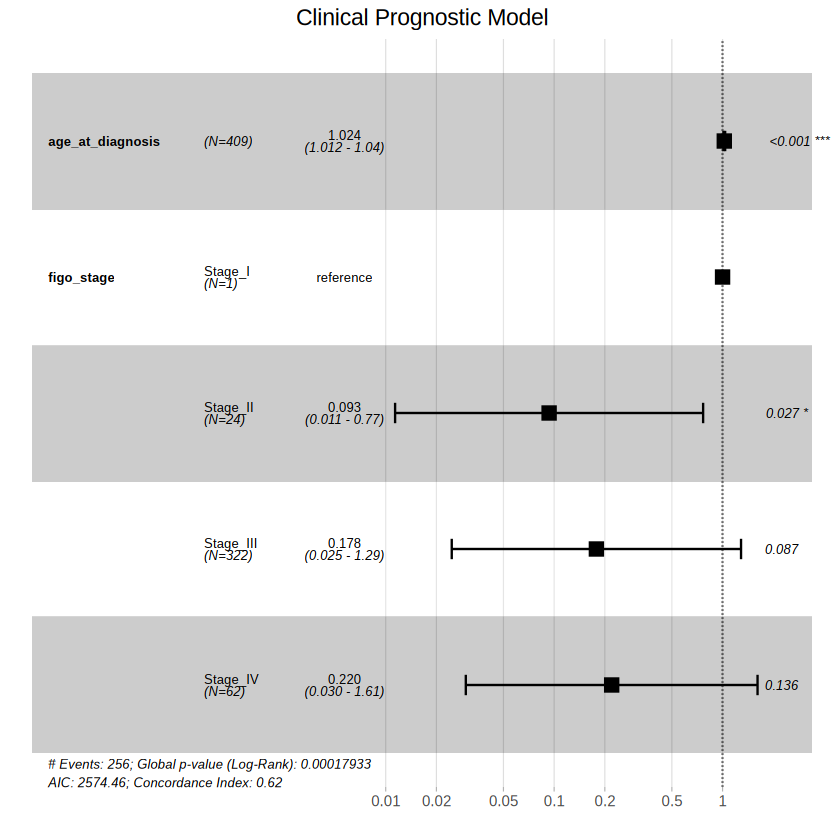

In [32]:
ggforest(
  cox_clinical,
  data = clinical_prognostic_df,
  main = "Clinical Prognostic Model",
  noDigits = 2
)

In [33]:
# png(filename = "./results/TCGA_clinical_prognostic_model.png", width = 1800, height = 1500, res = 300)
# ggforest(
#   cox_clinical,
#   data = clinical_prognostic_df,
#   main = "Clinical Prognostic Model",
#   #cpositions = c(0.02, 0.22, 0.4),
#   #fontsize = 1.0,
#   #refLabel = "Reference",
#   noDigits = 2
# )
# dev.off()

In [34]:
cox_combined <- coxph(
  Surv(OS_time, vital_status) ~ age_at_diagnosis + figo_stage + risk_score,
  data = clinical_prognostic_df
)

summary(cox_combined)

Call:
coxph(formula = Surv(OS_time, vital_status) ~ age_at_diagnosis + 
    figo_stage + risk_score, data = clinical_prognostic_df)

  n= 409, number of events= 256 

                         coef exp(coef)  se(coef)      z Pr(>|z|)    
age_at_diagnosis     0.017288  1.017438  0.006019  2.872  0.00408 ** 
figo_stageStage_II  -2.424899  0.088487  1.074804 -2.256  0.02406 *  
figo_stageStage_III -1.972935  0.139048  1.010292 -1.953  0.05084 .  
figo_stageStage_IV  -2.058425  0.127655  1.021341 -2.015  0.04386 *  
risk_score           0.984526  2.676544  0.109304  9.007  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                    exp(coef) exp(-coef) lower .95 upper .95
age_at_diagnosis      1.01744     0.9829   1.00551    1.0295
figo_stageStage_II    0.08849    11.3011   0.01076    0.7274
figo_stageStage_III   0.13905     7.1918   0.01920    1.0072
figo_stageStage_IV    0.12765     7.8336   0.01725    0.9449
risk_score            2.67654     0.3736

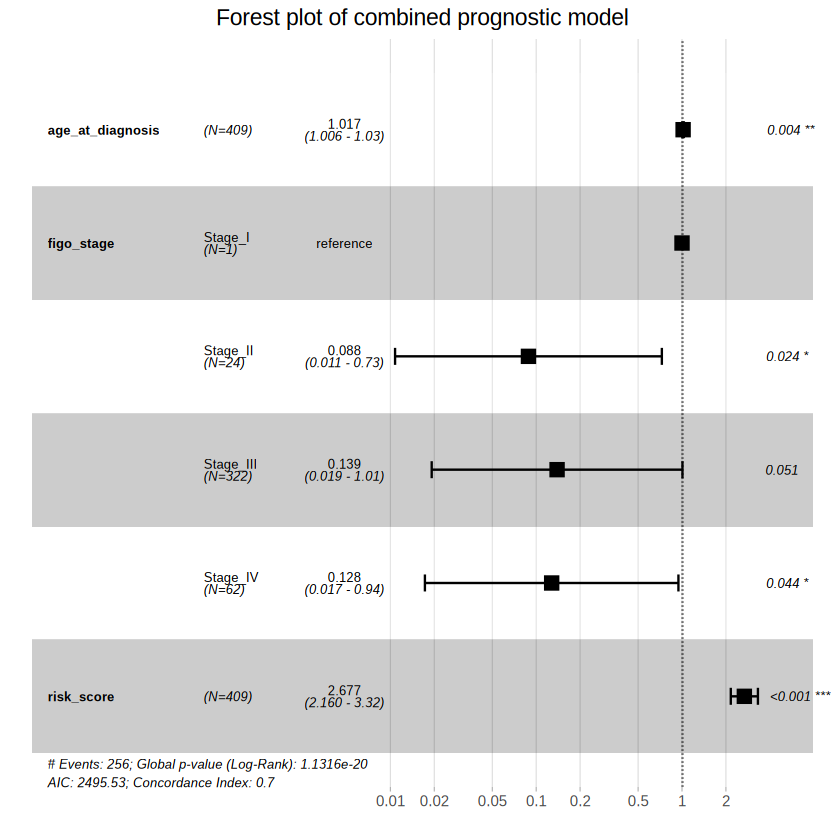

In [35]:
ggforest(
  cox_combined,
  data = clinical_prognostic_df,
  main = "Forest plot of combined prognostic model",
  noDigits = 2
)

In [36]:
# png(filename = "./results/TCGA_combined_prognostic_model.png", width = 1800, height = 1500, res = 300)
# ggforest(
#   cox_combined,
#   data = clinical_prognostic_df,
#   main = "Combined Prognostic Model",
#   #cpositions = c(0.02, 0.22, 0.4),
#   #fontsize = 1.0,
#   #refLabel = "Reference",
#   noDigits = 2
# )
# dev.off()